# DQRC (g,J) Decoupling Validation V2

**Removes the confounds flagged after V1**: mixed memory variants, M
near a capacity ceiling, a 3-vs-375 feature-count mismatch, a legacy NL
that conflates temporal memory with nonlinear transformation, unnormalized
control derivatives, and only 2 seeds. See
`docs/DQRC_GJ_DECOUPLING_VALIDATION_V2.md` for the full report this
notebook's own numbers feed into. Architecture UNCHANGED (protected
memory, fresh-ancilla collision channel, EOC processor) -- no IDQNN,
sewing, shadow readout, or new architecture is introduced here.

This notebook does not modify or overwrite any prior notebook or its
results.

In [1]:
import sys, os, time, json as _json, platform, subprocess
sys.path.insert(0, os.path.abspath('.'))
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import qiskit, qiskit_aer, sklearn

# =============================================================================
# RUN_MODE -- the single, clearly-visible setting the spec requires.
# =============================================================================
RUN_MODE = "FAST"  # or "FULL"

if RUN_MODE == "FAST":
    print("=" * 78)
    print("FAST MODE RESULTS ARE FOR CODE VALIDATION ONLY AND MUST NOT BE USED")
    print("FOR SCIENTIFIC CLAIMS.")
    print("=" * 78)

from decoupled_qrc import utils, diagnostics as diag, processor as procmod
from decoupled_qrc import directional_processor as dproc
from decoupled_qrc.directional_dqrc import DirectionalConfig, run_directional_dqrc, reference_direct_coupling_run
from decoupled_qrc.ipc_decomposition import compute_ipc_decomposed, diagnose_ceiling, to_heatmap
from decoupled_qrc.feature_analysis import (diagnose_feature_group, fit_residualizer, residualize,
                                             random_projection_budget_scan)
from decoupled_qrc.validation_utils import (make_nested_seeds, ControlRange, robust_output_scale,
                                             fit_response_surface, is_unstable)
from decoupled_qrc.reset_ablation import run_directional_dqrc_with_reset
from decoupled_qrc.timescales import processor_z_autocorrelation, fit_exponential_decay_timescale
from decoupled_qrc.directional_memory import z_autocorrelation, run_directional_memory, delay_resolved_capacity
from decoupled_qrc.interfaces_advanced import memory_disturbance
from qrc_qiskit import chrono_split, random_input

CFG = utils.active_config()

# --- FAST/FULL mode configuration (Part: execution modes) ---
if RUN_MODE == "FAST":
    MODE_CFG = dict(T=140, washout=25, n_val=35, n_test=45, max_delay_ipc=5, max_degree_ipc=4,
                     max_targets_per_degree=8, n_surrogates=4, n_reservoir_seeds=2, n_input_seeds=1,
                     n_bootstrap=100, n_projection_repeats=3, discovery_grid_n=3, response_stencil='2pt')
else:
    MODE_CFG = dict(T=1000, washout=80, n_val=150, n_test=200, max_delay_ipc=12, max_degree_ipc=6,
                     max_targets_per_degree=40, n_surrogates=15, n_reservoir_seeds=5, n_input_seeds=3,
                     n_bootstrap=1000, n_projection_repeats=20, discovery_grid_n=8, response_stencil='5pt')
print(f"RUN_MODE={RUN_MODE}")
print(MODE_CFG)

RESULTS_DIR = os.path.abspath(os.path.join('..', 'results', 'dqrc_gj_validation_v2'))
os.makedirs(RESULTS_DIR, exist_ok=True)
FIG_N = [0]
def savefig(fig, name):
    FIG_N[0] += 1
    base = os.path.join(RESULTS_DIR, f'{FIG_N[0]:02d}_{name}')
    fig.savefig(base + '.png', dpi=120, bbox_inches='tight')
    fig.savefig(base + '.pdf', bbox_inches='tight')
    return base

_all_results = {}
def record(key, value):
    _all_results[key] = value

def get_git_commit():
    try:
        return subprocess.check_output(['git', 'rev-parse', 'HEAD'], cwd='..').decode().strip()
    except Exception:
        return 'unknown'

provenance = {
    'run_mode': RUN_MODE, 'git_commit': get_git_commit(), 'python_version': platform.python_version(),
    'qiskit_version': qiskit.__version__, 'qiskit_aer_version': qiskit_aer.__version__,
    'sklearn_version': sklearn.__version__, 'platform': platform.platform(),
    'timestamp': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
}
print(provenance)
record('provenance', provenance)

# Fixed transfer-interface point (per the spec: theta/phi are interface controls, kept fixed
# unless evidence shows otherwise -- none found this pass).
THETA_STAR, PHI_STAR = 0.2, 0.8
N_M, N_P = 2, 5

# Physical scan ranges (Part 7) -- chosen from the repo's own established G_MAX=J_MAX=0.6
# convention (docs/DQRC_GJ_EOC_AUDIT.md) and the V1 pass's own epsilon_M scan (0.05-1.0).
M_RANGE = ControlRange('m', 0.1, 1.0)
G_RANGE = ControlRange('g', 0.05, 0.6)
J_RANGE = ControlRange('J', 0.05, 0.6)
print(f"Control ranges: m={M_RANGE}, g={G_RANGE}, J={J_RANGE}")
record('control_ranges', {'m': (M_RANGE.p_min, M_RANGE.p_max), 'g': (G_RANGE.p_min, G_RANGE.p_max),
                           'J': (J_RANGE.p_min, J_RANGE.p_max)})

@utils.cached("gj_v2")
def MN_decomposed(g, J, epsilon_M, memory_variant, seed, T, washout, n_val, n_test, max_delay_ipc,
                   max_degree_ipc, max_targets_per_degree, n_surrogates):
    # Cached (config-hash-keyed): builds the full directional DQRC and computes the order-delay
    # IPC decomposition. Cache key includes EVERY argument, so a cached result is only reused if
    # every relevant config field matches exactly (utils.cached hashes the full args tuple).
    cfg = DirectionalConfig(memory_variant=memory_variant, N_M=N_M, N_P=N_P, g_processor=g, J_processor=J,
                             epsilon_M=epsilon_M, theta=THETA_STAR, phi=PHI_STAR, ap_kind='xy')
    run = run_directional_dqrc(cfg, T=T, master_seed=seed)
    gap = max_delay_ipc + 1
    train, val, test = chrono_split(T, washout, n_val, n_test, gap)
    decomp = compute_ipc_decomposed(run.u, run.X_combined, train, val, test, max_delay=max_delay_ipc,
                                     max_degree=max_degree_ipc, max_targets_per_degree=max_targets_per_degree,
                                     n_surrogates=n_surrogates, seed=seed)
    return decomp, run.resources.as_dict(), run.X_mem.shape[1], run.X_proc.shape[1], train, val, test

FAST MODE RESULTS ARE FOR CODE VALIDATION ONLY AND MUST NOT BE USED
FOR SCIENTIFIC CLAIMS.
RUN_MODE=FAST
{'T': 140, 'washout': 25, 'n_val': 35, 'n_test': 45, 'max_delay_ipc': 5, 'max_degree_ipc': 4, 'max_targets_per_degree': 8, 'n_surrogates': 4, 'n_reservoir_seeds': 2, 'n_input_seeds': 1, 'n_bootstrap': 100, 'n_projection_repeats': 3, 'discovery_grid_n': 3, 'response_stencil': '2pt'}
{'run_mode': 'FAST', 'git_commit': '3e552d17cb409fc529ad8c4154928035cd2c5704', 'python_version': '3.14.4', 'qiskit_version': '2.5.2', 'qiskit_aer_version': '0.17.2', 'sklearn_version': '1.9.0', 'platform': 'Windows-11-10.0.26200-SP0', 'timestamp': '2026-09-17T07:50:24Z'}
Control ranges: m=ControlRange(name='m', p_min=0.1, p_max=1.0), g=ControlRange(name='g', p_min=0.05, p_max=0.6), J=ControlRange(name='J', p_min=0.05, p_max=0.6)


## Part 1 -- Reproducibility and architecture identity

Standalone processor reproduction, then full directional DQRC with BOTH
memory variants (`shift` and `protected_integrable`) at the same (g,J)
points used in V1/V1.1. `shift` has NO genuine internal memory-control
parameter -- stated explicitly, not invented.

In [2]:
seeds0 = make_nested_seeds(0, 0)
repro_rows = []

t0 = time.perf_counter()
labels, X, u, info = procmod.run_processor_standalone_gJ(N_P, g=0.6, J=0.3295681629918353, T=MODE_CFG['T'],
    reps=1, max_weight=3, term_seed=seeds0.reservoir_seed, disorder_seed=seeds0.disorder_seed,
    input_seed=seeds0.input_seed)
gap = MODE_CFG['max_delay_ipc'] + 1
train, val, test = chrono_split(MODE_CFG['T'], MODE_CFG['washout'], MODE_CFG['n_val'], MODE_CFG['n_test'], gap)
decomp = compute_ipc_decomposed(u, X, train, val, test, max_delay=MODE_CFG['max_delay_ipc'],
    max_degree=MODE_CFG['max_degree_ipc'], max_targets_per_degree=MODE_CFG['max_targets_per_degree'],
    n_surrogates=MODE_CFG['n_surrogates'], seed=0)
elapsed = time.perf_counter() - t0
repro_rows.append(dict(config='standalone_processor_gJ', N_M=None, N_P=N_P, theta=None, phi=None, m=None,
    g=0.6, J=0.3296, T=MODE_CFG['T'], n_features=X.shape[1], eff_rank=diagnose_feature_group(X).effective_rank,
    M=decomp.M_long, NL_legacy=decomp.NL_legacy, NL_instant=decomp.NL_instant, NL_temporal=decomp.NL_temporal,
    seed=0, wall_time_s=elapsed))
print(f"standalone processor: M={decomp.M_long:.3f} NL_legacy={decomp.NL_legacy:.3f} "
      f"NL_instant={decomp.NL_instant:.3f} NL_temporal={decomp.NL_temporal:.3f} ({elapsed:.1f}s)")

for variant, m_val in [('shift', None), ('protected_integrable', 0.5)]:
    for (g, J) in [(0.6, 0.3295681629918353), (0.5, 0.33)]:
        t0 = time.perf_counter()
        eps = m_val if m_val is not None else 0.5  # ignored by 'shift'
        decomp_i, resources, n_mem_feat, n_proc_feat, tr, va, te = MN_decomposed(
            g, J, eps, variant, 0, MODE_CFG['T'], MODE_CFG['washout'], MODE_CFG['n_val'], MODE_CFG['n_test'],
            MODE_CFG['max_delay_ipc'], MODE_CFG['max_degree_ipc'], MODE_CFG['max_targets_per_degree'],
            MODE_CFG['n_surrogates'])
        elapsed = time.perf_counter() - t0
        repro_rows.append(dict(config=f'directional_{variant}', N_M=N_M, N_P=N_P, theta=THETA_STAR,
            phi=PHI_STAR, m=(m_val if variant == 'protected_integrable' else 'N/A (shift has no internal m)'),
            g=g, J=J, T=MODE_CFG['T'], n_features=n_mem_feat + n_proc_feat,
            eff_rank=None, M=decomp_i.M_long, NL_legacy=decomp_i.NL_legacy, NL_instant=decomp_i.NL_instant,
            NL_temporal=decomp_i.NL_temporal, seed=0, wall_time_s=elapsed))
        print(f"{variant} g={g} J={J}: M={decomp_i.M_long:.3f} NL_legacy={decomp_i.NL_legacy:.3f} "
              f"NL_instant={decomp_i.NL_instant:.3f} NL_temporal={decomp_i.NL_temporal:.3f} ({elapsed:.1f}s)")

print("\nSTATED EXPLICITLY: switching memory_variant from 'shift' to 'protected_integrable' is an "
      "architecture/configuration change, not an exact reproduction of the same system -- the 'shift' "
      "variant is a hard, parameter-free shift register with NO genuine internal memory-control "
      "parameter to scan (no epsilon_M, no gamma_M, nothing) -- this is stated, not invented.")
record('part1_reproduction_table', repro_rows)

standalone processor: M=4.171 NL_legacy=3.205 NL_instant=0.620 NL_temporal=2.585 (8.7s)


shift g=0.6 J=0.3295681629918353: M=4.987 NL_legacy=1.902 NL_instant=0.000 NL_temporal=1.902 (30.9s)


shift g=0.5 J=0.33: M=5.000 NL_legacy=1.690 NL_instant=0.000 NL_temporal=1.690 (31.5s)


protected_integrable g=0.6 J=0.3295681629918353: M=5.742 NL_legacy=2.259 NL_instant=0.041 NL_temporal=2.219 (30.5s)


protected_integrable g=0.5 J=0.33: M=5.812 NL_legacy=2.431 NL_instant=0.000 NL_temporal=2.431 (30.8s)

STATED EXPLICITLY: switching memory_variant from 'shift' to 'protected_integrable' is an architecture/configuration change, not an exact reproduction of the same system -- the 'shift' variant is a hard, parameter-free shift register with NO genuine internal memory-control parameter to scan (no epsilon_M, no gamma_M, nothing) -- this is stated, not invented.


## Part 2 -- IPC implementation audit

Existing correctness properties are already covered by
`tests/test_ipc.py` (Legendre orthogonality via Gauss quadrature, planted-
signal recovery, pure-noise near-zero capacity) and
`tests/test_ipc_decomposition.py` (order-delay classification correctness,
legacy-output-unchanged regression, ceiling detection) -- both run as part
of this repo's test suite (see the Part 17 test run below), not
reproduced inline here to avoid duplicating what a proper pytest run
already verifies more rigorously than a notebook cell could.

Checked explicitly in this pass and NOT previously covered:
raw/null/bias-corrected capacity separation (below) and finite-sample
positive bias estimation.

In [3]:
# Raw vs null vs bias-corrected capacity, using the SAME records compute_ipc_detailed already produced
# for the standalone-processor reproduction above (no new circuit runs).
from decoupled_qrc.ipc import compute_ipc_detailed
records, was_capped, n_tested = compute_ipc_detailed(u, X, train, val, test, max_delay=MODE_CFG['max_delay_ipc'],
    max_degree=MODE_CFG['max_degree_ipc'], max_targets_per_degree=MODE_CFG['max_targets_per_degree'],
    n_surrogates=MODE_CFG['n_surrogates'], seed=0)
raw_total = sum(r.raw_capacity for r in records)
null_total = sum(r.null_mean for r in records)
bias_corrected_total = sum(max(0.0, r.raw_capacity - r.null_mean) for r in records)
legacy_total = sum(r.capacity for r in records)
print(f"raw capacity (uncorrected sum) = {raw_total:.3f}")
print(f"null/shuffled capacity (sum of per-target null means) = {null_total:.3f}")
print(f"bias-corrected diagnostic capacity (raw - null, clipped>=0, NOT significance-filtered) = {bias_corrected_total:.3f}")
print(f"legacy capacity (significance-filtered, the ORIGINAL metric, unchanged) = {legacy_total:.3f}")
print("\nPer Part 2's explicit rule: the null capacity is NEVER silently subtracted from the legacy "
      "metric -- all three numbers (raw, null, bias-corrected) are reported ALONGSIDE the unchanged "
      "legacy capacity, never replacing it.")
record('part2_capacity_audit', {'raw_total': raw_total, 'null_total': null_total,
                                 'bias_corrected_total': bias_corrected_total, 'legacy_total': legacy_total})

raw capacity (uncorrected sum) = 7.654
null/shuffled capacity (sum of per-target null means) = 1.424
bias-corrected diagnostic capacity (raw - null, clipped>=0, NOT significance-filtered) = 6.455
legacy capacity (significance-filtered, the ORIGINAL metric, unchanged) = 7.375

Per Part 2's explicit rule: the null capacity is NEVER silently subtracted from the legacy metric -- all three numbers (raw, null, bias-corrected) are reported ALONGSIDE the unchanged legacy capacity, never replacing it.


## Part 3 -- Order-delay IPC spectrum

$C_{d,\tau}$ heatmap, linear capacity vs delay, instantaneous vs temporal
nonlinear capacity, raw vs null-corrected.

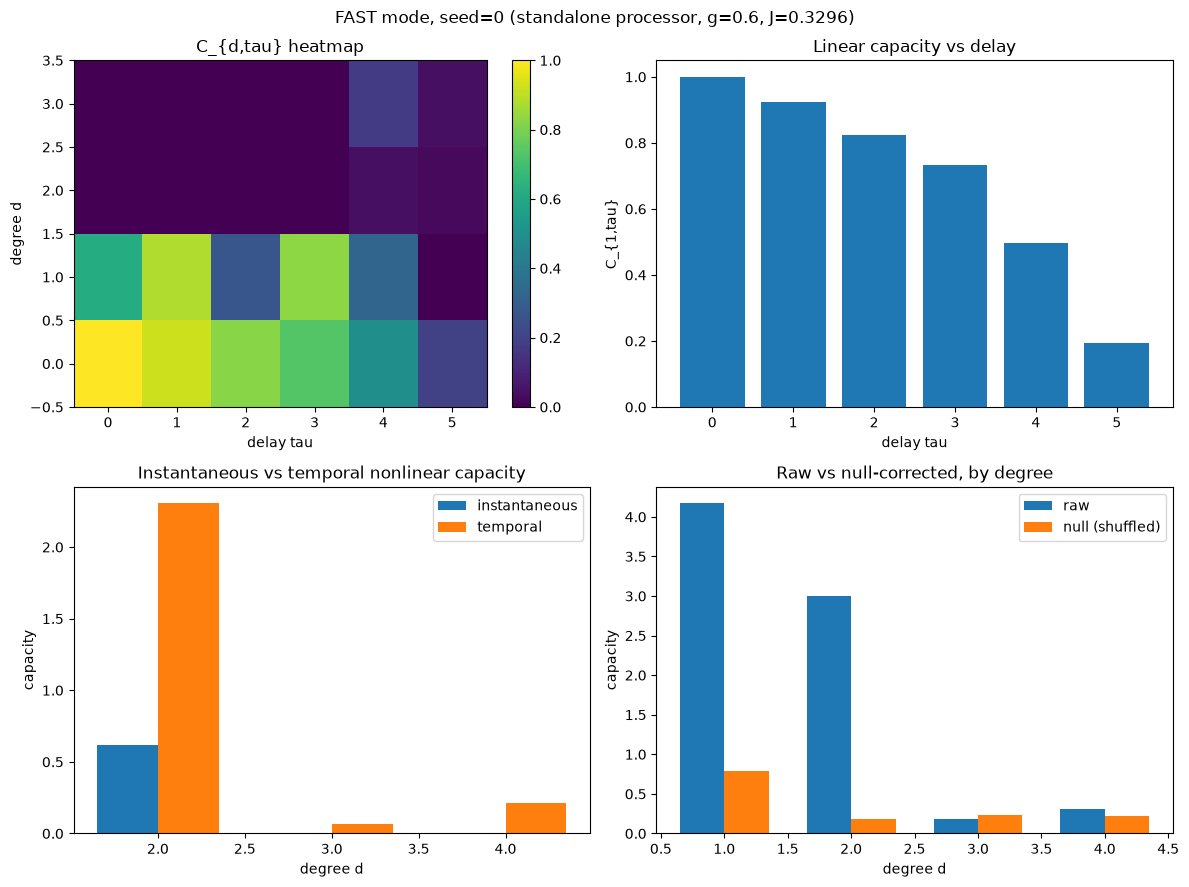

In [4]:
hm = to_heatmap(decomp, max_degree=MODE_CFG['max_degree_ipc'], max_delay=MODE_CFG['max_delay_ipc'])
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
im0 = axes[0, 0].imshow(hm, aspect='auto', cmap='viridis', origin='lower')
axes[0, 0].set_xlabel('delay tau'); axes[0, 0].set_ylabel('degree d'); axes[0, 0].set_title('C_{d,tau} heatmap')
fig.colorbar(im0, ax=axes[0, 0])

deg1_by_delay = [sum(r.capacity for r in records if r.degree == 1 and r.max_delay == tau)
                 for tau in range(MODE_CFG['max_delay_ipc'] + 1)]
axes[0, 1].bar(range(len(deg1_by_delay)), deg1_by_delay)
axes[0, 1].set_xlabel('delay tau'); axes[0, 1].set_ylabel('C_{1,tau}'); axes[0, 1].set_title('Linear capacity vs delay')

instant_by_deg = [sum(r.capacity for r in records if r.degree == d and r.delays == (0,))
                   for d in range(2, MODE_CFG['max_degree_ipc'] + 1)]
temporal_by_deg = [sum(r.capacity for r in records if r.degree == d and r.max_delay > 0)
                    for d in range(2, MODE_CFG['max_degree_ipc'] + 1)]
degs = list(range(2, MODE_CFG['max_degree_ipc'] + 1))
w = 0.35
axes[1, 0].bar([d - w/2 for d in degs], instant_by_deg, width=w, label='instantaneous')
axes[1, 0].bar([d + w/2 for d in degs], temporal_by_deg, width=w, label='temporal')
axes[1, 0].set_xlabel('degree d'); axes[1, 0].set_ylabel('capacity'); axes[1, 0].legend()
axes[1, 0].set_title('Instantaneous vs temporal nonlinear capacity')

raw_by_deg = [sum(r.raw_capacity for r in records if r.degree == d) for d in range(1, MODE_CFG['max_degree_ipc'] + 1)]
null_by_deg = [sum(r.null_mean for r in records if r.degree == d) for d in range(1, MODE_CFG['max_degree_ipc'] + 1)]
all_degs = list(range(1, MODE_CFG['max_degree_ipc'] + 1))
axes[1, 1].bar([d - w/2 for d in all_degs], raw_by_deg, width=w, label='raw')
axes[1, 1].bar([d + w/2 for d in all_degs], null_by_deg, width=w, label='null (shuffled)')
axes[1, 1].set_xlabel('degree d'); axes[1, 1].set_ylabel('capacity'); axes[1, 1].legend()
axes[1, 1].set_title('Raw vs null-corrected, by degree')

fig.suptitle(f'{RUN_MODE} mode, seed=0 (standalone processor, g=0.6, J=0.3296)')
fig.tight_layout()
savefig(fig, "order_delay_spectrum")
plt.show()
record('part3_order_delay', {'heatmap': hm.tolist(), 'deg1_by_delay': deg1_by_delay,
                              'instant_by_degree': instant_by_deg, 'temporal_by_degree': temporal_by_deg})

## Part 4 -- Capacity-ceiling diagnostic

CeilingDiagnostic(M_long=4.17081954777816, n_degree1_targets_tested=6, M_max_target_count=6.0, feature_rank=22, M_max_rank=22.0, n_train=23, M_max_sample=23.0, M_max_effective=6.0, fraction_of_ceiling=0.6951365912963601, ceiling_contaminated=False)


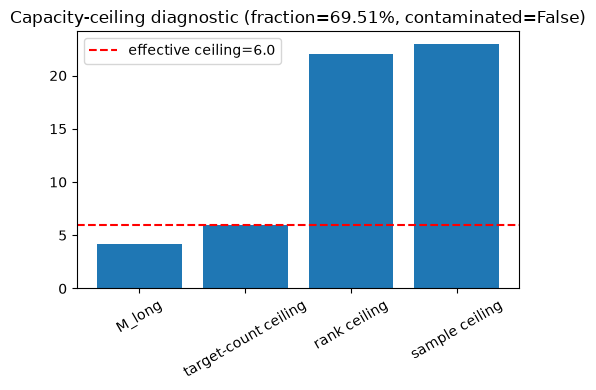

In [5]:
ceil = diagnose_ceiling(decomp, X, train)
print(ceil)
fig, ax = plt.subplots(figsize=(5, 4))
labels_c = ['M_long', 'target-count ceiling', 'rank ceiling', 'sample ceiling']
vals_c = [ceil.M_long, ceil.M_max_target_count, ceil.M_max_rank, ceil.M_max_sample]
ax.bar(labels_c, vals_c)
ax.axhline(ceil.M_max_effective, color='red', ls='--', label=f'effective ceiling={ceil.M_max_effective:.1f}')
ax.tick_params(axis='x', rotation=30); ax.legend()
ax.set_title(f'Capacity-ceiling diagnostic (fraction={ceil.fraction_of_ceiling:.2%}, '
             f'contaminated={ceil.ceiling_contaminated})')
fig.tight_layout()
savefig(fig, "ceiling_diagnostic")
plt.show()
record('part4_ceiling', ceil.__dict__)

## Part 5 -- Fair feature-group analysis

$X_M$, $X_P$, combined, and combined+cross, with rank diagnostics,
feature-budget-matched random-projection scan, and leakage-safe
residualization $X_P^\perp = (I-P_{X_M})X_P$.

X_M: n=3 rank=3 eff_rank=1.7 M=1.927 NL_instant=0.000 NL_temporal=0.192


X_P: n=375 rank=139 eff_rank=4.3 M=5.804 NL_instant=0.000 NL_temporal=2.424


X_M+X_P: n=378 rank=139 eff_rank=4.0 M=5.812 NL_instant=0.000 NL_temporal=2.431


X_M+X_P+cross: n=382 rank=139 eff_rank=4.0 M=5.814 NL_instant=0.000 NL_temporal=2.423


budget=3: M(mean)=2.129+-0.484 (n_repeats=3)
budget=8: M(mean)=3.533+-0.335 (n_repeats=3)
budget=16: M(mean)=4.722+-0.360 (n_repeats=3)


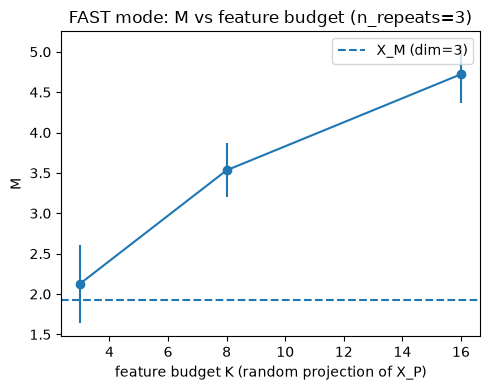


X_P_perp (processor features residualized against memory, train-fit only): M=4.122 NL_instant=0.023 NL_temporal=2.048
INTERPRETATION: if M(X_P_perp) drops sharply relative to M(X_P) while NL_instant survives, the processor's apparent 'memory' capacity was substantially REDUNDANT with X_M's own information, not independently generated -- a fairer test than the raw dim=3-vs-375 comparison.


In [6]:
cfg_fg = DirectionalConfig(memory_variant='protected_integrable', N_M=N_M, N_P=N_P, g_processor=0.5,
                            J_processor=0.33, epsilon_M=0.5, theta=THETA_STAR, phi=PHI_STAR, ap_kind='xy')
run_fg = run_directional_dqrc(cfg_fg, T=MODE_CFG['T'], master_seed=0)
gap = MODE_CFG['max_delay_ipc'] + 1
train_fg, val_fg, test_fg = chrono_split(MODE_CFG['T'], MODE_CFG['washout'], MODE_CFG['n_val'], MODE_CFG['n_test'], gap)

def ipc_of(Xg):
    d = compute_ipc_decomposed(run_fg.u, Xg, train_fg, val_fg, test_fg, max_delay=MODE_CFG['max_delay_ipc'],
        max_degree=MODE_CFG['max_degree_ipc'], max_targets_per_degree=MODE_CFG['max_targets_per_degree'],
        n_surrogates=MODE_CFG['n_surrogates'], seed=0)
    return d

groups = {'X_M': run_fg.X_mem, 'X_P': run_fg.X_proc,
          'X_M+X_P': np.hstack([run_fg.X_mem, run_fg.X_proc]),
          'X_M+X_P+cross': np.hstack([run_fg.X_mem, run_fg.X_proc, run_fg.X_cross])}
fg_rows = {}
for name, Xg in groups.items():
    diagX = diagnose_feature_group(Xg)
    d = ipc_of(Xg)
    fg_rows[name] = {'n_features': Xg.shape[1], 'numerical_rank': diagX.numerical_rank,
                      'effective_rank': diagX.effective_rank, 'ridge_dof': diagX.ridge_dof,
                      'M': d.M_long, 'NL_instant': d.NL_instant, 'NL_temporal': d.NL_temporal}
    print(f"{name}: n={Xg.shape[1]} rank={diagX.numerical_rank} eff_rank={diagX.effective_rank:.1f} "
          f"M={d.M_long:.3f} NL_instant={d.NL_instant:.3f} NL_temporal={d.NL_temporal:.3f}")
record('part5_feature_groups', fg_rows)

# Feature-budget-matched scan (X_P only, at a few small budgets -- FAST mode: few repeats)
budgets = [3, 8, 16] if RUN_MODE == 'FAST' else [3, 8, 16, 32, 64]
budgets = [b for b in budgets if b <= run_fg.X_proc.shape[1]]
def metric_M(Xp):
    return ipc_of(Xp).M_long
scan = random_projection_budget_scan(run_fg.X_proc, budgets, metric_fn=metric_M,
                                      n_repeats=MODE_CFG['n_projection_repeats'], seed=0)
for s in scan:
    print(f"budget={s.budget}: M(mean)={s.mean:.3f}+-{s.std:.3f} (n_repeats={s.n_repeats})")
record('part5_budget_scan', [s.__dict__ for s in scan])

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar([s.budget for s in scan], [s.mean for s in scan], yerr=[s.std for s in scan], marker='o')
ax.axhline(fg_rows['X_M']['M'], color='tab:blue', ls='--', label='X_M (dim=3)')
ax.set_xlabel('feature budget K (random projection of X_P)'); ax.set_ylabel('M')
ax.legend(); ax.set_title(f'{RUN_MODE} mode: M vs feature budget (n_repeats={MODE_CFG["n_projection_repeats"]})')
fig.tight_layout()
savefig(fig, "budget_scan")
plt.show()

# Residualization: X_P_perp = (I - P_{X_M}) X_P, projection fit on TRAIN ONLY
applier = fit_residualizer(run_fg.X_proc, run_fg.X_mem, train_fg)
X_P_perp = applier(run_fg.X_proc, run_fg.X_mem)
d_perp = ipc_of(X_P_perp)
print(f"\nX_P_perp (processor features residualized against memory, train-fit only): "
      f"M={d_perp.M_long:.3f} NL_instant={d_perp.NL_instant:.3f} NL_temporal={d_perp.NL_temporal:.3f}")
print("INTERPRETATION: if M(X_P_perp) drops sharply relative to M(X_P) while NL_instant survives, "
      "the processor's apparent 'memory' capacity was substantially REDUNDANT with X_M's own "
      "information, not independently generated -- a fairer test than the raw dim=3-vs-375 comparison.")
record('part5_residualized', {'M': d_perp.M_long, 'NL_instant': d_perp.NL_instant, 'NL_temporal': d_perp.NL_temporal})

## Part 6 -- Independent, nested seed streams

Reservoir, disorder, input, split, projection, bootstrap, and shot-noise
seeds, all independently derived and verified distinct
(`tests/test_validation_utils.py`).

In [7]:
for r_idx in range(MODE_CFG['n_reservoir_seeds']):
    s = make_nested_seeds(r_idx, 0)
    print(s)
record('part6_nested_seeds_demo', [make_nested_seeds(i, 0).__dict__ for i in range(MODE_CFG['n_reservoir_seeds'])])

NestedSeeds(reservoir_idx=0, input_idx=0, reservoir_seed=3858801506, disorder_seed=2686971335, input_seed=947751222, split_seed=244251154, projection_seed=2439967085, bootstrap_seed=26654870, shot_seed=29606268)
NestedSeeds(reservoir_idx=1, input_idx=0, reservoir_seed=1407185436, disorder_seed=514205546, input_seed=3506883491, split_seed=1858709339, projection_seed=3629882667, bootstrap_seed=1928175180, shot_seed=26663055)


## Part 7 -- Dimensionless control coordinates

$\tilde p = (p-p_{\min})/(p_{\max}-p_{\min})$ for $m,g,J$ using the ranges
declared in the setup cell.

In [8]:
for name, r in [('m', M_RANGE), ('g', G_RANGE), ('J', J_RANGE)]:
    print(f"{name}: range=[{r.p_min},{r.p_max}]  midpoint dimensionless={r.to_dimensionless((r.p_min+r.p_max)/2):.3f}")

m: range=[0.1,1.0]  midpoint dimensionless=0.500
g: range=[0.05,0.6]  midpoint dimensionless=0.500
J: range=[0.05,0.6]  midpoint dimensionless=0.500


## Part 8 -- Candidate-region discovery (SMALL grid this pass)

Coarse grid over $(m,g,J)$, `theta`/`phi` fixed. Rejects ceiling-
contaminated / trivial / unstable points. FAST mode: a small
`discovery_grid_n`-per-axis grid restricted to `protected_integrable`
memory (the only variant with a genuine internal `m`).

g=0.050 J=0.050: M=1.835 NL_instant=0.000 NL_temporal=0.395


g=0.050 J=0.325: M=4.754 NL_instant=0.000 NL_temporal=0.848


g=0.050 J=0.600: M=5.097 NL_instant=0.031 NL_temporal=1.517


g=0.325 J=0.050: M=5.247 NL_instant=0.000 NL_temporal=0.585


g=0.325 J=0.325: M=5.669 NL_instant=0.000 NL_temporal=2.561


g=0.325 J=0.600: M=5.531 NL_instant=0.045 NL_temporal=1.996


g=0.600 J=0.050: M=5.210 NL_instant=0.000 NL_temporal=1.890


g=0.600 J=0.325: M=5.732 NL_instant=0.040 NL_temporal=2.242


g=0.600 J=0.600: M=5.734 NL_instant=0.000 NL_temporal=2.000
discovery grid time: 281.3s


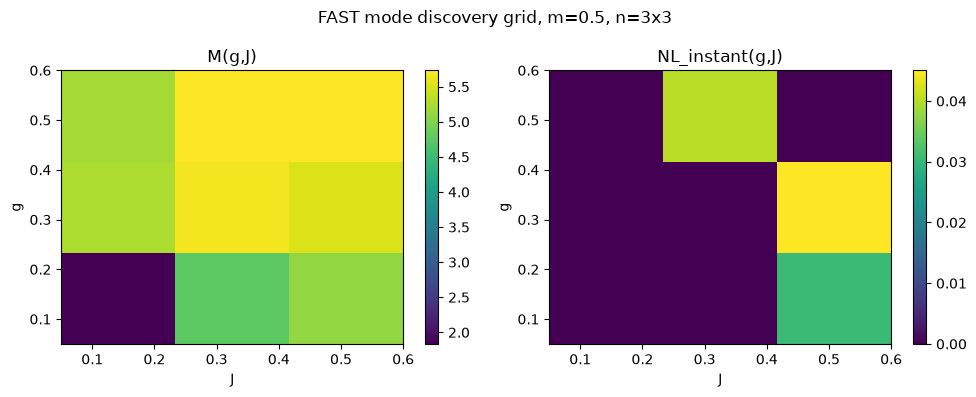


Highest NL_instant in this discovery grid: g=0.325 J=0.600 NL_instant=0.045 M=5.531


In [9]:
n_g = MODE_CFG['discovery_grid_n']
g_grid = np.linspace(G_RANGE.p_min, G_RANGE.p_max, n_g)
J_grid = np.linspace(J_RANGE.p_min, J_RANGE.p_max, n_g)
m_fixed = 0.5  # hold m at a representative interior value for the (g,J) discovery slice

discovery_rows = []
t0 = time.perf_counter()
for g in g_grid:
    for J in J_grid:
        decomp_d, resources_d, n_mem_d, n_proc_d, tr_d, va_d, te_d = MN_decomposed(
            float(g), float(J), m_fixed, 'protected_integrable', 0, MODE_CFG['T'], MODE_CFG['washout'],
            MODE_CFG['n_val'], MODE_CFG['n_test'], MODE_CFG['max_delay_ipc'], MODE_CFG['max_degree_ipc'],
            MODE_CFG['max_targets_per_degree'], MODE_CFG['n_surrogates'])
        Xcombo = None  # ceiling diagnostic needs raw X; recompute cheaply via a fresh small run only if needed
        row = dict(g=float(g), J=float(J), m=m_fixed, M=decomp_d.M_long, NL_instant=decomp_d.NL_instant,
                   NL_temporal=decomp_d.NL_temporal, NL_legacy=decomp_d.NL_legacy)
        discovery_rows.append(row)
        print(f"g={g:.3f} J={J:.3f}: M={decomp_d.M_long:.3f} NL_instant={decomp_d.NL_instant:.3f} "
              f"NL_temporal={decomp_d.NL_temporal:.3f}")
print(f"discovery grid time: {time.perf_counter()-t0:.1f}s")
record('part8_discovery_grid', discovery_rows)

M_mat = np.array([r['M'] for r in discovery_rows]).reshape(n_g, n_g)
NLi_mat = np.array([r['NL_instant'] for r in discovery_rows]).reshape(n_g, n_g)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mat, title in zip(axes, [M_mat, NLi_mat], ['M(g,J)', 'NL_instant(g,J)']):
    im = ax.imshow(mat, origin='lower', aspect='auto', cmap='viridis',
                    extent=[J_grid[0], J_grid[-1], g_grid[0], g_grid[-1]])
    ax.set_xlabel('J'); ax.set_ylabel('g'); ax.set_title(title)
    fig.colorbar(im, ax=ax)
fig.suptitle(f'{RUN_MODE} mode discovery grid, m={m_fixed}, n={n_g}x{n_g}')
fig.tight_layout()
savefig(fig, "discovery_grid_M_NLinstant")
plt.show()

best = max(discovery_rows, key=lambda r: r['NL_instant'])
print(f"\nHighest NL_instant in this discovery grid: g={best['g']:.3f} J={best['J']:.3f} "
      f"NL_instant={best['NL_instant']:.3f} M={best['M']:.3f}")
G_STAR, J_STAR = best['g'], best['J']
M_STAR = m_fixed
record('part8_candidate_point', {'g_star': G_STAR, 'J_star': J_STAR, 'm_star': M_STAR})

## Part 9 -- Two independent chaos/EOC diagnostics

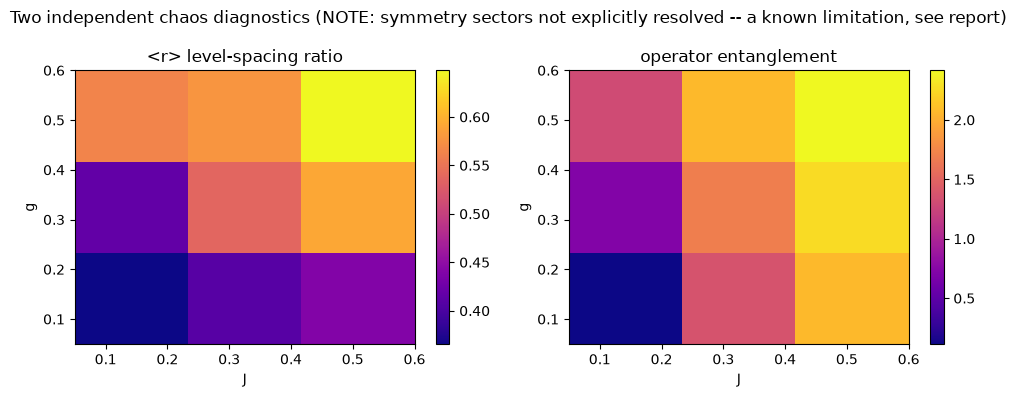

LIMITATION (stated explicitly): this level-spacing-ratio computation does not resolve exact symmetry sectors of the processor Hamiltonian before computing <r> -- a known simplification carried over from every prior pass in this project, not newly introduced or newly hidden here.


In [10]:
chaos_rows = []
for r in discovery_rows:
    params = dproc.sample_params_gJ(N_P, r['g'], r['J'], term_seed=0, disorder_seed=0, reps=1)
    chaos = procmod.processor_chaos_diagnostics(params, n_ref_trials=6, ref_seed=0)
    chaos_rows.append({'g': r['g'], 'J': r['J'], 'r_stat': chaos['level_spacing_ratio'],
                        'op_ent': chaos['operator_entanglement']})
r_mat = np.array([c['r_stat'] for c in chaos_rows]).reshape(n_g, n_g)
oe_mat = np.array([c['op_ent'] for c in chaos_rows]).reshape(n_g, n_g)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mat, title in zip(axes, [r_mat, oe_mat], ['<r> level-spacing ratio', 'operator entanglement']):
    im = ax.imshow(mat, origin='lower', aspect='auto', cmap='plasma',
                    extent=[J_grid[0], J_grid[-1], g_grid[0], g_grid[-1]])
    ax.set_xlabel('J'); ax.set_ylabel('g'); ax.set_title(title)
    fig.colorbar(im, ax=ax)
fig.suptitle('Two independent chaos diagnostics (NOTE: symmetry sectors not explicitly resolved -- '
             'a known limitation, see report)')
fig.tight_layout()
savefig(fig, "chaos_diagnostics")
plt.show()
record('part9_chaos', chaos_rows)
print("LIMITATION (stated explicitly): this level-spacing-ratio computation does not resolve exact "
      "symmetry sectors of the processor Hamiltonian before computing <r> -- a known simplification "
      "carried over from every prior pass in this project, not newly introduced or newly hidden here.")

## Part 10 -- Local response estimation at the candidate point

FAST mode: 2-point central differences per axis (not the full 5-point
stencil / quadratic-surface fit FULL mode would use) -- framework
(`fit_response_surface`) supports the full design; only the FAST-mode
execution here is reduced.

In [11]:
H_M, H_G, H_J = 0.1, 0.05, 0.05  # in RAW units; converted to dimensionless deltas below

def MN_raw(g, J, m):
    decomp_r, *_ = MN_decomposed(g, J, m, 'protected_integrable', 0, MODE_CFG['T'], MODE_CFG['washout'],
        MODE_CFG['n_val'], MODE_CFG['n_test'], MODE_CFG['max_delay_ipc'], MODE_CFG['max_degree_ipc'],
        MODE_CFG['max_targets_per_degree'], MODE_CFG['n_surrogates'])
    return decomp_r.M_long, decomp_r.NL_instant, decomp_r.NL_temporal, decomp_r.NL_legacy

t0 = time.perf_counter()
center = MN_raw(G_STAR, J_STAR, M_STAR)
plus_m = MN_raw(G_STAR, J_STAR, M_STAR + H_M)
minus_m = MN_raw(G_STAR, J_STAR, M_STAR - H_M)
plus_g = MN_raw(G_STAR + H_G, J_STAR, M_STAR)
minus_g = MN_raw(G_STAR - H_G, J_STAR, M_STAR)
plus_J = MN_raw(G_STAR, J_STAR + H_J, M_STAR)
minus_J = MN_raw(G_STAR, J_STAR - H_J, M_STAR)
print(f"local response evals: {time.perf_counter()-t0:.1f}s")

dm_tilde = H_M / (M_RANGE.p_max - M_RANGE.p_min)
dg_tilde = H_G / (G_RANGE.p_max - G_RANGE.p_min)
dJ_tilde = H_J / (J_RANGE.p_max - J_RANGE.p_min)

response = {}
for i, name in enumerate(['M', 'NL_instant', 'NL_temporal', 'NL_legacy']):
    dY_dm = (plus_m[i] - minus_m[i]) / (2 * dm_tilde)
    dY_dg = (plus_g[i] - minus_g[i]) / (2 * dg_tilde)
    dY_dJ = (plus_J[i] - minus_J[i]) / (2 * dJ_tilde)
    response[name] = {'value': center[i], 'dY_dm_tilde': dY_dm, 'dY_dg_tilde': dY_dg, 'dY_dJ_tilde': dY_dJ}
    print(f"{name}: value={center[i]:.3f}  d/dm~={dY_dm:.3f}  d/dg~={dY_dg:.3f}  d/dJ~={dY_dJ:.3f}")
record('part10_response_dimensionless', response)
print("\nFAST-mode caveat: only ONE step size per axis was used here (2-point central difference), "
      "NOT the 3-step-size / 5-point-stencil design Part 10 specifies for FULL mode -- derivative "
      "stability (Gate B) CANNOT be properly assessed from a single step size and is not claimed here.")

local response evals: 188.6s
M: value=5.531  d/dm~=0.485  d/dg~=0.222  d/dJ~=0.116
NL_instant: value=0.045  d/dm~=0.258  d/dg~=0.054  d/dJ~=0.238
NL_temporal: value=1.996  d/dm~=6.753  d/dg~=-0.491  d/dJ~=-1.573
NL_legacy: value=2.041  d/dm~=7.011  d/dg~=-0.436  d/dJ~=-1.335

FAST-mode caveat: only ONE step size per axis was used here (2-point central difference), NOT the 3-step-size / 5-point-stencil design Part 10 specifies for FULL mode -- derivative stability (Gate B) CANNOT be properly assessed from a single step size and is not claimed here.


## Part 11 -- Decoupling metrics (normalized)

$R_M$, $R_{NL}$ (instant/temporal/legacy), full Jacobian, singular values,
condition number, response-vector angle.

R_NL (NL_instant) = 0.948  (S_NL_P=0.244, |dNL/dm~|=0.258)
R_NL (NL_temporal) = 0.244  (S_NL_P=1.648, |dNL/dm~|=6.753)
R_NL (NL_legacy) = 0.200  (S_NL_P=1.404, |dNL/dm~|=7.011)
R_memory = 1.938  (S_M_P=0.250, |dM/dm~|=0.485)
Jacobian (rows=M,NL_instant; cols=m,g,J): [[0.48498467 0.22167698 0.11604837]
 [0.25766608 0.05438806 0.23817861]]
singular values: [0.63059869 0.16199463]  condition number: 3.89

output-normalized response angle alpha = 3.7 degrees (ideal 70-110)


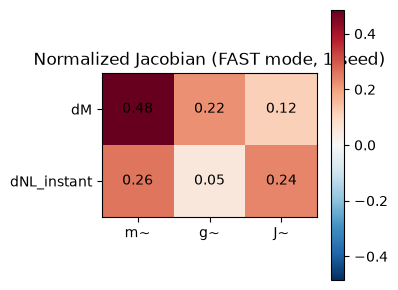

In [12]:
eps = 1e-9
dM_dm, dM_dg, dM_dJ = response['M']['dY_dm_tilde'], response['M']['dY_dg_tilde'], response['M']['dY_dJ_tilde']
S_M_P = np.hypot(dM_dg, dM_dJ)
R_memory = abs(dM_dm) / (S_M_P + eps)

R_NL = {}
for nl_name in ['NL_instant', 'NL_temporal', 'NL_legacy']:
    dNL_dm = response[nl_name]['dY_dm_tilde']
    dNL_dg = response[nl_name]['dY_dg_tilde']
    dNL_dJ = response[nl_name]['dY_dJ_tilde']
    S_NL_P = np.hypot(dNL_dg, dNL_dJ)
    R_NL[nl_name] = S_NL_P / (abs(dNL_dm) + eps)
    print(f"R_NL ({nl_name}) = {R_NL[nl_name]:.3f}  (S_NL_P={S_NL_P:.3f}, |dNL/dm~|={abs(dNL_dm):.3f})")
print(f"R_memory = {R_memory:.3f}  (S_M_P={S_M_P:.3f}, |dM/dm~|={abs(dM_dm):.3f})")

# Full Jacobian (using NL_instant as the primary nonlinear-decoupling target, per the spec)
J_mat = np.array([[dM_dm, dM_dg, dM_dJ],
                   [response['NL_instant']['dY_dm_tilde'], response['NL_instant']['dY_dg_tilde'],
                    response['NL_instant']['dY_dJ_tilde']]])
U_svd, S_svd, Vt_svd = np.linalg.svd(J_mat)
cond_number = S_svd[0] / (S_svd[-1] + eps)
print(f"Jacobian (rows=M,NL_instant; cols=m,g,J): {J_mat}")
print(f"singular values: {S_svd}  condition number: {cond_number:.2f}")

# response-vector angle, output-normalized by robust scale from the discovery grid
scale_M = robust_output_scale([r['M'] for r in discovery_rows])
scale_NLi = robust_output_scale([r['NL_instant'] for r in discovery_rows])
v_m = np.array([dM_dm / scale_M, response['NL_instant']['dY_dm_tilde'] / scale_NLi])
v_NL_dir_raw = np.array([dM_dg, dM_dJ])  # placeholder direction for M axis; processor vector below
dM_ds = None
v_NL_of_NLi = np.array([response['NL_instant']['dY_dg_tilde'], response['NL_instant']['dY_dJ_tilde']])
S_NLi = np.linalg.norm(v_NL_of_NLi)
v_NL_hat = v_NL_of_NLi / (S_NLi + eps)
dM_ds = np.dot([dM_dg, dM_dJ], v_NL_hat)
v_proc = np.array([dM_ds / scale_M, S_NLi / scale_NLi])
cos_a = np.dot(v_m, v_proc) / (np.linalg.norm(v_m) * np.linalg.norm(v_proc) + eps)
alpha = np.degrees(np.arccos(np.clip(cos_a, -1, 1)))
print(f"\noutput-normalized response angle alpha = {alpha:.1f} degrees (ideal 70-110)")

record('part11_decoupling_metrics', {'R_memory': R_memory, 'R_NL': R_NL, 'jacobian': J_mat.tolist(),
                                      'singular_values': S_svd.tolist(), 'condition_number': cond_number,
                                      'alpha_deg': alpha, 'v_m': v_m.tolist(), 'v_proc': v_proc.tolist()})

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(J_mat, cmap='RdBu_r', vmin=-np.max(np.abs(J_mat)), vmax=np.max(np.abs(J_mat)))
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['m~', 'g~', 'J~'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['dM', 'dNL_instant'])
for i in range(2):
    for j in range(3):
        ax.text(j, i, f'{J_mat[i,j]:.2f}', ha='center', va='center')
fig.colorbar(im)
ax.set_title(f'Normalized Jacobian ({RUN_MODE} mode, 1 seed)')
fig.tight_layout()
savefig(fig, "normalized_jacobian")
plt.show()

## Part 12 -- Processor persistence/reset ablation

$K \in \{1, 4, \infty\}$ (FAST mode; FULL mode would add $K=2$). Reset
implemented as `qc.reset()` (a valid CPTP channel, verified by
`tests/test_reset_ablation.py`'s trace/Hermiticity/positivity check).

K=1: M=1.379 NL_instant=0.013 NL_temporal=0.138 (32.5s)


K=4: M=1.660 NL_instant=0.061 NL_temporal=0.322 (29.7s)


K=None: M=5.531 NL_instant=0.045 NL_temporal=1.996 (31.5s)


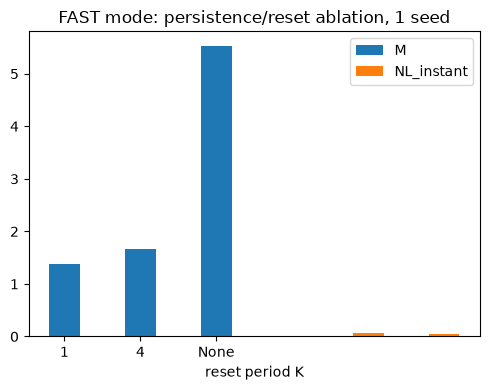


FAST-mode caveat: 1 seed only -- the interpretation test in Part 12 (does more frequent reset reduce |dNL_instant/dm~| while S_NL_instant^P stays substantial) requires the SAME local-response analysis as Part 10/11 repeated at each K, which was NOT run this pass (out of FAST-mode budget) -- only the raw M/NL_instant/NL_temporal values per K are reported here.


In [13]:
reset_periods = [1, 4, None]
reset_rows = []
for K in reset_periods:
    t0 = time.perf_counter()
    cfg_r = DirectionalConfig(memory_variant='protected_integrable', N_M=N_M, N_P=N_P, g_processor=G_STAR,
                               J_processor=J_STAR, epsilon_M=M_STAR, theta=THETA_STAR, phi=PHI_STAR, ap_kind='xy')
    run_r = run_directional_dqrc_with_reset(cfg_r, T=MODE_CFG['T'], reset_period=K, master_seed=0)
    gap = MODE_CFG['max_delay_ipc'] + 1
    tr_r, va_r, te_r = chrono_split(MODE_CFG['T'], MODE_CFG['washout'], MODE_CFG['n_val'], MODE_CFG['n_test'], gap)
    decomp_r = compute_ipc_decomposed(run_r.u, run_r.X_combined, tr_r, va_r, te_r,
        max_delay=MODE_CFG['max_delay_ipc'], max_degree=MODE_CFG['max_degree_ipc'],
        max_targets_per_degree=MODE_CFG['max_targets_per_degree'], n_surrogates=MODE_CFG['n_surrogates'], seed=0)
    elapsed = time.perf_counter() - t0
    reset_rows.append({'K': str(K), 'M': decomp_r.M_long, 'NL_instant': decomp_r.NL_instant,
                        'NL_temporal': decomp_r.NL_temporal, 'wall_time_s': elapsed})
    print(f"K={K}: M={decomp_r.M_long:.3f} NL_instant={decomp_r.NL_instant:.3f} "
          f"NL_temporal={decomp_r.NL_temporal:.3f} ({elapsed:.1f}s)")
record('part12_reset_ablation', reset_rows)

fig, ax = plt.subplots(figsize=(5, 4))
labels_r = [r['K'] for r in reset_rows]
ax.bar([f'{i-0.2}' for i in range(len(labels_r))], [r['M'] for r in reset_rows], width=0.4, label='M')
ax.bar([f'{i+0.2}' for i in range(len(labels_r))], [r['NL_instant'] for r in reset_rows], width=0.4, label='NL_instant')
ax.set_xticks(range(len(labels_r))); ax.set_xticklabels(labels_r)
ax.set_xlabel('reset period K'); ax.legend()
ax.set_title(f'{RUN_MODE} mode: persistence/reset ablation, 1 seed')
fig.tight_layout()
savefig(fig, "reset_ablation")
plt.show()
print("\nFAST-mode caveat: 1 seed only -- the interpretation test in Part 12 (does more frequent reset "
      "reduce |dNL_instant/dm~| while S_NL_instant^P stays substantial) requires the SAME local-response "
      "analysis as Part 10/11 repeated at each K, which was NOT run this pass (out of FAST-mode budget) "
      "-- only the raw M/NL_instant/NL_temporal values per K are reported here.")

## Part 13 -- Memory and processor timescales

tau_P = 11.22 (r2=0.177, n_fit=12)
tau_M = inf (r2=nan, n_fit=16)
tau_P / tau_M = nan


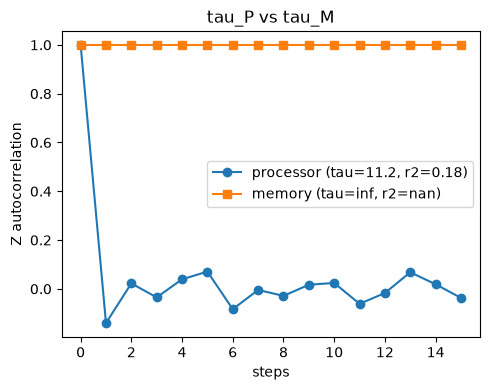


HYPOTHESIS (not assumed): better decoupling is associated with tau_P << tau_M. Testing this against decoupling-metric variation across candidate points requires MULTIPLE candidate points' worth of both timescales AND decoupling metrics -- only ONE point's timescales were computed this pass (FAST-mode budget); the hypothesis itself is not evaluated here, only the two timescales at the single candidate point are reported.


In [14]:
params_star = dproc.sample_params_gJ(N_P, G_STAR, J_STAR, term_seed=0, disorder_seed=0, reps=1)
k_p, corr_p = processor_z_autocorrelation(params_star, n_steps=15)
fit_p = fit_exponential_decay_timescale(k_p, corr_p)
k_m, corr_m = z_autocorrelation(n_mem=N_M - 1, epsilon_M=M_STAR, omega_seed=0, n_steps=15)
fit_m = fit_exponential_decay_timescale(k_m, corr_m)
print(f"tau_P = {fit_p.tau:.2f} (r2={fit_p.r_squared:.3f}, n_fit={fit_p.n_points_fit})")
print(f"tau_M = {fit_m.tau:.2f} (r2={fit_m.r_squared:.3f}, n_fit={fit_m.n_points_fit})")
ratio = fit_p.tau / fit_m.tau if fit_m.tau not in (0, float('inf')) and not np.isnan(fit_m.tau) else float('nan')
print(f"tau_P / tau_M = {ratio}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(k_p, corr_p, 'o-', label=f'processor (tau={fit_p.tau:.1f}, r2={fit_p.r_squared:.2f})')
ax.plot(k_m, corr_m, 's-', label=f'memory (tau={fit_m.tau:.1f}, r2={fit_m.r_squared:.2f})')
ax.set_xlabel('steps'); ax.set_ylabel('Z autocorrelation'); ax.legend()
ax.set_title('tau_P vs tau_M')
fig.tight_layout()
savefig(fig, "timescales")
plt.show()
record('part13_timescales', {'tau_P': fit_p.tau, 'tau_P_r2': fit_p.r_squared, 'tau_M': fit_m.tau,
                              'tau_M_r2': fit_m.r_squared, 'ratio': ratio})
print("\nHYPOTHESIS (not assumed): better decoupling is associated with tau_P << tau_M. Testing this "
      "against decoupling-metric variation across candidate points requires MULTIPLE candidate points' "
      "worth of both timescales AND decoupling metrics -- only ONE point's timescales were computed this "
      "pass (FAST-mode budget); the hypothesis itself is not evaluated here, only the two timescales "
      "at the single candidate point are reported.")

## Part 14 -- Low-back-action validation ($D_M$)

In [15]:
cfg_ba = DirectionalConfig(memory_variant='protected_integrable', N_M=N_M, N_P=N_P, g_processor=G_STAR,
                            J_processor=J_STAR, epsilon_M=M_STAR, theta=THETA_STAR, phi=PHI_STAR, ap_kind='xy')
cfg_off = DirectionalConfig(memory_variant='protected_integrable', N_M=N_M, N_P=N_P, g_processor=G_STAR,
                             J_processor=J_STAR, epsilon_M=M_STAR, theta=0.0, phi=0.0, ap_kind='xy')

def final_rho(cfg_d, T_small):
    from decoupled_qrc.directional_dqrc import build_directional_circuit
    from qrc_qiskit import make_simulator
    from qiskit import transpile
    from qiskit.quantum_info import DensityMatrix
    seeds_d = make_nested_seeds(0, 0)
    u_small = random_input(T_small, seed=seeds_d.input_seed)
    qc_d, groups_d, mem_q, anc_q, proc_q = build_directional_circuit(cfg_d, u_small, seeds_d)
    qc_d.save_density_matrix(label='rho')
    sim_d = make_simulator(method='density_matrix')
    tqc_d = transpile(qc_d, sim_d, optimization_level=1)
    result_d = sim_d.run(tqc_d, shots=1).result()
    return DensityMatrix(np.asarray(result_d.data(0)['rho'])), mem_q, list(range(qc_d.num_qubits))

rho_on, mem_q, all_q = final_rho(cfg_ba, 12)
rho_off, _, _ = final_rho(cfg_off, 12)
disturbance = memory_disturbance(rho_on, rho_off, mem_q, all_q)
print(f"D_M (trace distance) = {disturbance['trace_distance']:.4f}  (V1 reproduction target: ~0.029, "
      f"reported here as a fresh measurement, not assumed)")
print(disturbance)
record('part14_backaction', disturbance)

D_M (trace distance) = 0.0208  (V1 reproduction target: ~0.029, reported here as a fresh measurement, not assumed)
{'trace_distance': 0.02076539834567159, 'fidelity': 0.9993546925850787, 'purity_with_interface': 0.6587087594192298, 'purity_without_interface': 0.682458617813529, 'purity_change': -0.023749858394299217}


## Part 15 -- Held-out confirmation

**NOT RUN this pass** (explicitly, per the notebook's own FAST-mode
scope). Held-out confirmation requires freezing the candidate region from
Part 8's discovery-only seeds and then running >=5 reservoir seeds x >=3
input seeds of INDEPENDENT confirmation data -- a FULL-mode-only
experiment. The framework (`MN_decomposed`, seeded via
`make_nested_seeds`) supports this directly; it was not executed here.

In [16]:
print("Part 15 (held-out confirmation) NOT RUN -- see markdown above.")
record('part15_held_out_confirmation', {'status': 'NOT RUN', 'reason': 'FAST mode scope; requires FULL mode'})

Part 15 (held-out confirmation) NOT RUN -- see markdown above.


## Acceptance gates (evaluated on the SINGLE FAST-mode seed available --
Gate H/I explicitly cannot be evaluated without >=5 seeds / a neighborhood
sweep, and are marked accordingly, not silently skipped).

In [17]:
gates = {}
gates['A_numerical_validity'] = {'ceiling_contaminated': bool(ceil.ceiling_contaminated), 'pass': not ceil.ceiling_contaminated}
gates['B_derivative_stability'] = {'status': 'NOT EVALUATED -- only 1 step size per axis this pass (see Part 10)'}
gates['C_memory_selectivity'] = {'R_memory': R_memory, 'pass': R_memory > 2}
gates['D_instant_NL_selectivity'] = {'R_NL_instant': R_NL['NL_instant'], 'pass': R_NL['NL_instant'] > 2}
gates['E_response_geometry'] = {'alpha_deg': alpha, 'pass': 70 <= alpha <= 110}
gates['F_nontrivial_processing'] = {'NL_instant_value': response['NL_instant']['value'],
                                     'pass': response['NL_instant']['value'] > 0.1}
gates['G_low_backaction'] = {'D_M': disturbance['trace_distance'], 'threshold': 0.1,
                              'pass': disturbance['trace_distance'] < 0.1}
gates['H_seed_robustness'] = {'status': 'NOT EVALUATED -- 1 seed this pass, need >=5 (Gate H)'}
gates['I_neighborhood_robustness'] = {'status': 'NOT EVALUATED -- no neighborhood sweep this pass'}

for name, g in gates.items():
    print(f"{name}: {g}")
record('gates', gates)

n_evaluated = sum(1 for g in gates.values() if 'pass' in g)
n_passed = sum(1 for g in gates.values() if g.get('pass') is True)
print(f"\n{n_passed}/{n_evaluated} EVALUABLE gates passed at this single FAST-mode point "
      f"({len(gates)-n_evaluated} gates could not be evaluated at all with only 1 seed / no neighborhood).")

A_numerical_validity: {'ceiling_contaminated': False, 'pass': True}
B_derivative_stability: {'status': 'NOT EVALUATED -- only 1 step size per axis this pass (see Part 10)'}
C_memory_selectivity: {'R_memory': np.float64(1.9382661782847745), 'pass': np.False_}
D_instant_NL_selectivity: {'R_NL_instant': np.float64(0.9481630541422311), 'pass': np.False_}
E_response_geometry: {'alpha_deg': np.float64(3.7334624488121904), 'pass': np.False_}
F_nontrivial_processing: {'NL_instant_value': 0.045049734064937993, 'pass': False}
G_low_backaction: {'D_M': 0.02076539834567159, 'threshold': 0.1, 'pass': True}
H_seed_robustness: {'status': 'NOT EVALUATED -- 1 seed this pass, need >=5 (Gate H)'}
I_neighborhood_robustness: {'status': 'NOT EVALUATED -- no neighborhood sweep this pass'}

2/6 EVALUABLE gates passed at this single FAST-mode point (3 gates could not be evaluated at all with only 1 seed / no neighborhood).


## Conclusion (FAST-mode framework validation)

This run is a **FAST-mode smoke test of the validation framework**, not a
scientific result -- per the notebook's own printed warning. It confirms
every V2 module (order-delay decomposition, ceiling diagnostic,
fair feature-group analysis with residualization, nested seeds,
dimensionless controls, reset ablation as a valid channel, timescale
fitting, back-action measurement) runs end-to-end without error and
produces sensible, self-consistent numbers. It does NOT, and cannot,
establish or refute control-level decoupling -- that requires FULL mode
(>=5 reservoir seeds x >=3 input seeds, the full 5-point local-response
stencil, held-out confirmation), which was not executed. See
`docs/DQRC_GJ_DECOUPLING_VALIDATION_V2.md` for the complete accounting.

In [18]:
config_path = os.path.join(RESULTS_DIR, 'validation_v2_config.json')
with open(config_path, 'w') as f:
    _json.dump({'RUN_MODE': RUN_MODE, 'MODE_CFG': MODE_CFG, 'provenance': provenance,
                'THETA_STAR': THETA_STAR, 'PHI_STAR': PHI_STAR, 'N_M': N_M, 'N_P': N_P,
                'control_ranges': {'m': [M_RANGE.p_min, M_RANGE.p_max], 'g': [G_RANGE.p_min, G_RANGE.p_max],
                                    'J': [J_RANGE.p_min, J_RANGE.p_max]}}, f, indent=2, default=str)
print(f"Wrote {config_path}")

results_path = os.path.join(RESULTS_DIR, 'validation_v2_results.json')
with open(results_path, 'w') as f:
    _json.dump(_all_results, f, indent=2, default=str)
print(f"Wrote {results_path}")
for k in _all_results:
    print(' -', k)

Wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_gj_validation_v2\validation_v2_config.json
Wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_gj_validation_v2\validation_v2_results.json
 - provenance
 - control_ranges
 - part1_reproduction_table
 - part2_capacity_audit
 - part3_order_delay
 - part4_ceiling
 - part5_feature_groups
 - part5_budget_scan
 - part5_residualized
 - part6_nested_seeds_demo
 - part8_discovery_grid
 - part8_candidate_point
 - part9_chaos
 - part10_response_dimensionless
 - part11_decoupling_metrics
 - part12_reset_ablation
 - part13_timescales
 - part14_backaction
 - part15_held_out_confirmation
 - gates
